# Visualization for BEIR Results

Use this notebook to explore BEIR evaluation summaries saved under `reports/beir-metrics`.


## Instructions

1. Update `DATASET_DIR` below if you want to inspect another dataset.

2. Run the cells to load the summary CSV and generate Matplotlib figures.

3. Use the final cell to optionally save the chart as a PNG file for sharing.


In [9]:
from pathlib import Path

DATASET_DIR = Path('../reports/beir-metrics/webis-touche2020')
SUMMARY_PATH = DATASET_DIR / 'summary.csv'
SUMMARY_PATH

PosixPath('../reports/beir-metrics/webis-touche2020/summary.csv')

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f'Summary not found: {SUMMARY_PATH}')

df = pd.read_csv(SUMMARY_PATH)
display(df)


,ranker,k,NDCG,MAP,Recall,Precision
0,bubbly,1,0.27551,0.02770,0.02770,0.28571
1,bubbly,3,0.27262,0.06202,0.08392,0.29252
2,bubbly,5,0.25435,0.08535,0.12819,0.26531
3,bubbly,10,0.23623,0.11784,0.20671,0.20612
4,bubbly,100,0.52620,0.22527,1.00000,0.10000
5,random,1,0.13265,0.01405,0.01405,0.14286
6,random,3,0.11735,0.02736,0.04398,0.13605
7,random,5,0.11886,0.03534,0.06582,0.13061
8,random,10,0.11278,0.04440,0.10303,0.09796
9,random,100,0.45260,0.14779,1.00000,0.10000


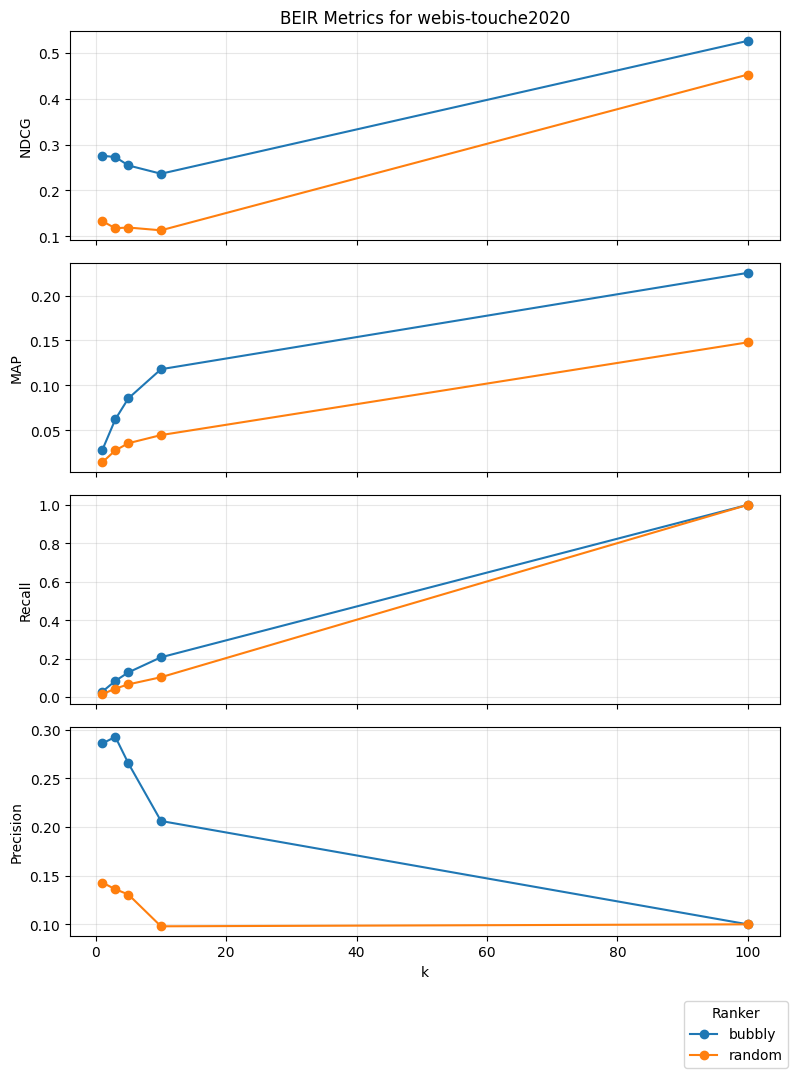

In [11]:
metrics = ['NDCG', 'MAP', 'Recall', 'Precision']
rankers = sorted(df['ranker'].unique())
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 10), sharex=True)
try:
    axes = axes.ravel().tolist()
except AttributeError:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    for ranker in rankers:
        subset = df[df['ranker'] == ranker].sort_values('k')
        ax.plot(subset['k'], subset[metric], marker='o', label=ranker)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)

axes[0].set_title(f'BEIR Metrics for {DATASET_DIR.name}')
axes[-1].set_xlabel('k')
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1, 0), title='Ranker')
fig.tight_layout()
plt.show()


In [12]:
OUTPUT_PNG = DATASET_DIR / 'matplotlib_metrics.png'
fig.savefig(OUTPUT_PNG, dpi=200, bbox_inches='tight')
OUTPUT_PNG

PosixPath('../reports/beir-metrics/webis-touche2020/matplotlib_metrics.png')